In [35]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("Raw_dataset.csv")

In [36]:
shape = df.shape
print(shape)

(953, 13)


##1. Data Analysis

###1.1 Dataset Overview

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            953 non-null    object 
 1   Gender             929 non-null    object 
 2   Married            949 non-null    object 
 3   Dependents         930 non-null    object 
 4   Education          953 non-null    object 
 5   Self_Employed      903 non-null    object 
 6   ApplicantIncome    953 non-null    int64  
 7   CoapplicantIncome  953 non-null    float64
 8   LoanAmount         921 non-null    float64
 9   Loan_Amount_Term   935 non-null    float64
 10  Credit_History     872 non-null    float64
 11  Property_Area      953 non-null    object 
 12  Loan_Status        953 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 96.9+ KB



The dataset contains 953 records and 13 attributes, including numerical and categorical data. Some attributes contain missing values, indicating that data cleaning is required during preprocessing.

###1.2 Statistical Summary

In [38]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,953.000000,953.000000,921.000000,935.000000,872.000000
mean,5433.144806,1671.703085,146.163952,340.979679,0.829128
std,6288.391469,3164.094759,84.654966,65.987724,0.376613
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2873.000000,0.000000,100.000000,360.000000,1.000000
50%,3775.000000,1250.000000,128.000000,360.000000,1.000000
75%,5818.000000,2306.000000,166.000000,360.000000,1.000000
max,81002.000000,41667.000000,700.000000,480.000000,1.000000


The statistical summary shows large differences between the mean and maximum values of ApplicantIncome and CoapplicantIncome, indicating skewed distributions and potential outliers. These attributes may require further analysis and normalization during preprocessing.

###1.3 Five-Number Summary

In [39]:
numeric_data= df[["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]]

In [40]:
min_data = numeric_data.min()
print(min_data)

ApplicantIncome      150.0
CoapplicantIncome      0.0
LoanAmount             9.0
Loan_Amount_Term      12.0
Credit_History         0.0
dtype: float64


In [41]:
quartiles = numeric_data.quantile([0.25,0.5,0.75], axis=0, numeric_only=True)
print(quartiles)

      ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0.25           2873.0                0.0       100.0             360.0   
0.50           3775.0             1250.0       128.0             360.0   
0.75           5818.0             2306.0       166.0             360.0   

      Credit_History  
0.25             1.0  
0.50             1.0  
0.75             1.0  


In [42]:
max_data = numeric_data.max()
print(max_data)

ApplicantIncome      81002.0
CoapplicantIncome    41667.0
LoanAmount             700.0
Loan_Amount_Term       480.0
Credit_History           1.0
dtype: float64


The five-number summary shows the minimum, Q1, median, Q3, and maximum values of the numerical attributes. The wide ranges in ApplicantIncome, CoapplicantIncome, and LoanAmount suggest potential outliers that should be investigated during preprocessing.

###1.4 Distribution of Numericcal Attributes

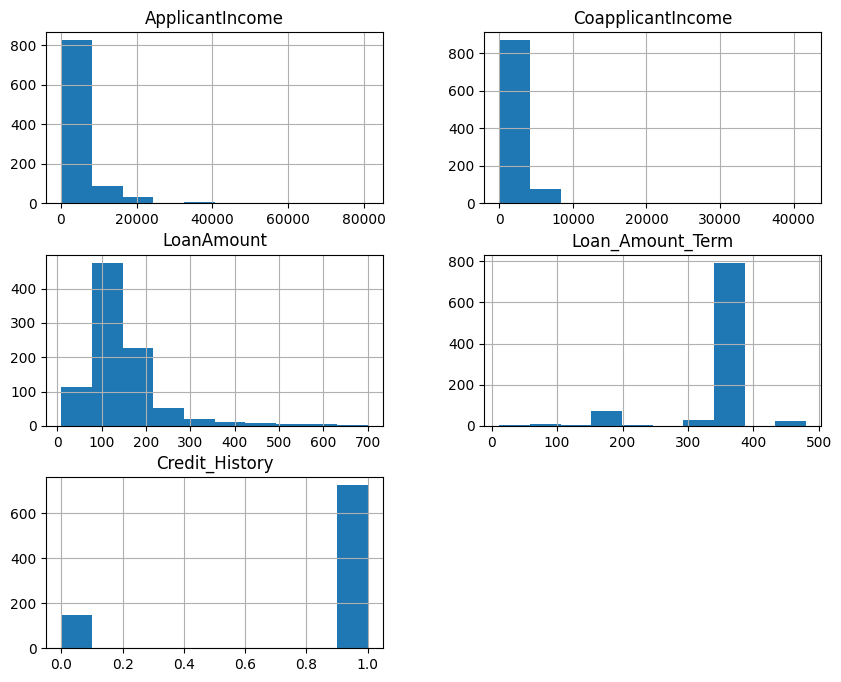

In [43]:
numeric_data.hist(figsize=(10,8))
plt.show()

The histograms show that ApplicantIncome, CoapplicantIncome, and LoanAmount are right-skewed, while Loan_Amount_Term is mostly concentrated around 360 and Credit_History around 1. These distributions suggest that outlier analysis and appropriate scaling should be considered during preprocessing.


###1.5 Missing Values Analysis

In [44]:
missing_values = df.isna().sum()
print("Missing values in each column : ")
print(missing_values)

Missing values in each column : 
Loan_ID               0
Gender               24
Married               4
Dependents           23
Education             0
Self_Employed        50
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           32
Loan_Amount_Term     18
Credit_History       81
Property_Area         0
Loan_Status           0
dtype: int64


The analysis identified missing values in Credit_History (81), Self_Employed (50), LoanAmount (32), Gender (24), Dependents (23), Loan_Amount_Term (18), and Married (4). These missing values need to be handled during preprocessing to improve data completeness.


###1.6 Boxplots for Numerical Attributes

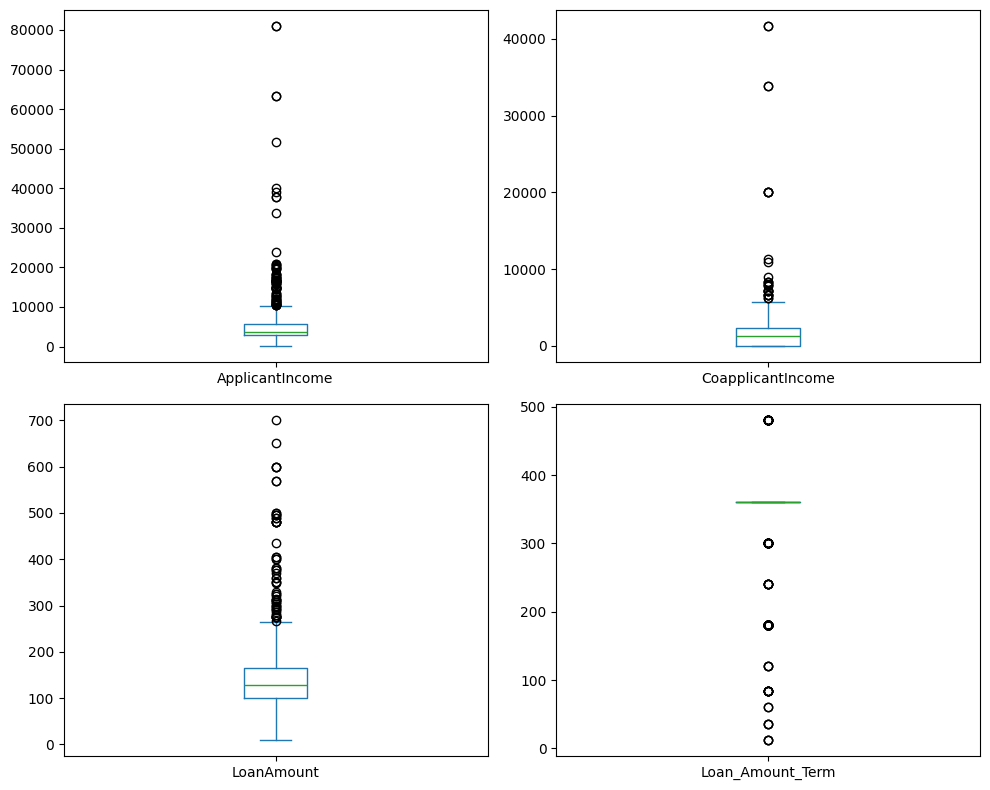

In [45]:
boxplot_data = df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]]
boxplot_data.plot (kind = "box", subplots = True, layout = (2, 2), figsize = (10, 8))
plt.tight_layout()
plt.show()

The boxplots show the distribution and potential outliers of the numerical attributes. Several outliers are visible, especially in ApplicantIncome, CoapplicantIncome, and LoanAmount. This indicates that the outliers should be further analyzed and considered during preprocessing.

###1.7 Outlier Analysis

In [46]:
Q1 = boxplot_data.quantile(0.25)
Q3 = boxplot_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

print("Lower Bound:")
print(lower_bound)
print("\nUpper Bound:")
print(upper_bound)


Lower Bound:
ApplicantIncome     -1544.5
CoapplicantIncome   -3459.0
LoanAmount              1.0
Loan_Amount_Term      360.0
dtype: float64

Upper Bound:
ApplicantIncome      10235.5
CoapplicantIncome     5765.0
LoanAmount             265.0
Loan_Amount_Term       360.0
dtype: float64


In [47]:
outliers = (boxplot_data < lower_bound) | (boxplot_data > upper_bound)

print("Number of outliers:")
print(outliers.sum())

Number of outliers:
ApplicantIncome       78
CoapplicantIncome     29
LoanAmount            60
Loan_Amount_Term     143
dtype: int64


Using the IQR method, 78 outliers were identified in ApplicantIncome, 29 in CoapplicantIncome, 60 in LoanAmount and 143 in Loan_Amount_Term. This shows that the numerical attributes contain unusual values that need to be considered during preprocessing.

###1.8 Scatter Plot

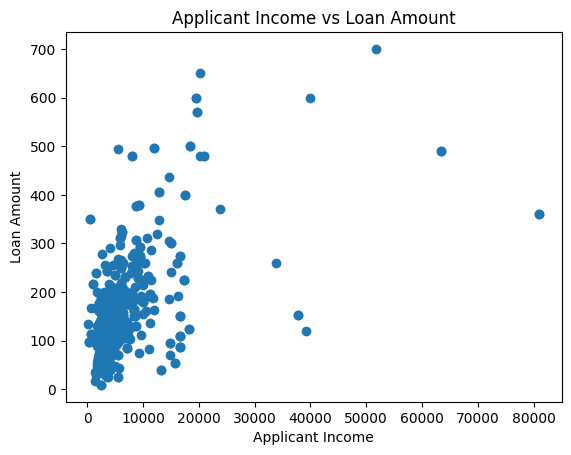

In [48]:
plt.scatter(df["ApplicantIncome"], df["LoanAmount"])
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Applicant Income vs Loan Amount")

plt.show()

The scatter plot shows the relationship between ApplicantIncome and LoanAmount. It suggests a positive relationship between the two attributes, with several unusual values far from the main cluster. These values indicate that the data may require preprocessing to handle potential outliers.

###1.9 Bar Plot for a Nominal Attribute

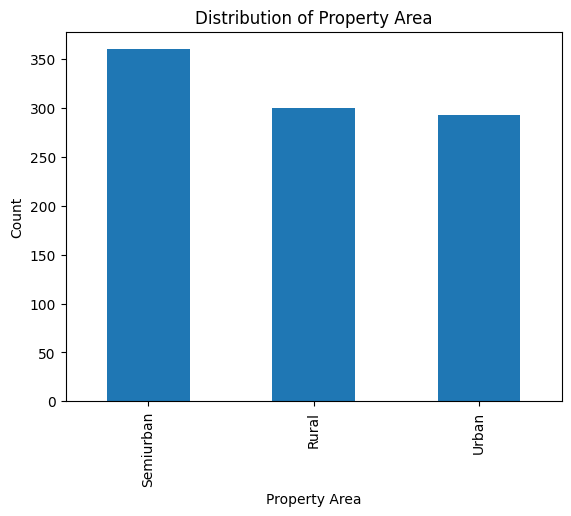

In [49]:
df["Property_Area"].value_counts().plot(kind="bar")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.title("Distribution of Property Area")

plt.show()

The bar plot shows the distribution of the Property_Area categories. Semiurban is the most common category, while Rural and Urban have lower and relatively similar counts. This distribution should be considered during preprocessing.

###1.10 Class Label Distribution

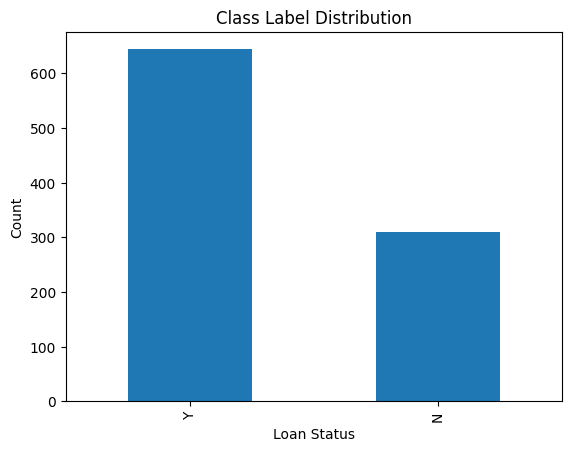

In [50]:
df["Loan_Status"].value_counts().plot(kind="bar")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.title("Class Label Distribution")

plt.show()

The class label distribution shows that Loan_Status is imbalanced, with more approved (Y) than rejected (N) applications. This class imbalance should be considered during preprocessing.

###1.11 Short Conclusion

The data analysis provided an overview and statistical summary of the dataset, including its numerical distributions and five-number summaries. The analysis also identified missing values, potential outliers, relationships between numerical attributes, differences in categorical distributions, and an imbalance in the class label. These findings show that preprocessing is needed to improve the dataset before further analysis and modeling.

##2 Data preprocessing
###2.1 Handling Missing Values

The dataset contains missing values in several attributes.
Missing values need to be handled before applying data mining techniques to improve data quality and avoid problems during the analysis and modeling process.

In [51]:
df.isnull().sum()

,0
Loan_ID,0
Gender,24
Married,4
Dependents,23
Education,0
Self_Employed,50
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,32
Loan_Amount_Term,18


####2.1.1 Categorical missing values
Missing values in categorical attributes were replaced using the mode.
The mode was used because these attributes contain categorical values.

In [52]:
categorical_columns = ['Gender', 'Married', 'Dependents', 'Self_Employed']
for column in categorical_columns:
    df[column]= df[column].fillna(df[column].mode()[0])

In [53]:
df[categorical_columns].isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Self_Employed,0


####2.1.2 Numerical missing values
For 'LoanAmount', missing values were replaced with the median because the median is less affected by extreme values.

For 'Loan_Amount_Term' and 'Credit_History', missing values were replaced with the mode because these attributes contain a limited set of discrete values.

In [54]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(
    df['Loan_Amount_Term'].mode()[0]
)

df['Credit_History'] = df['Credit_History'].fillna(
    df['Credit_History'].mode()[0]
  )

In [55]:
df[['LoanAmount' , 'Loan_Amount_Term' , 'Credit_History']].isnull().sum()

,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [56]:
df.to_csv('MissingValues_Handled.csv' , index=False)

###2.2 Encoding

Loan_Status is the target attribute and contains two categorical labels: Y (approved) and N (not approved)

Label Encoding was applied to this attribute to represent the target labels numerically for classification. Using LabelEncoder, N was converted to 0 and Y was converted to 1. This changes the representation of the labels while preserving their meaning

Before Encoding

In [57]:
print(df['Loan_Status'].head(5))

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: object


Applying Label Encoding

In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

After Encoding

In [59]:
print(df['Loan_Status'].head(5))

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


The before-and-after samples show that Loan_Status changed from text labels to numeric labels. The encoding preserved the approval categories and did not remove any records or change other attributes.

###2.3 Outlier Handling
ApplicantIncome was selected because it contains extreme values that are considerably higher than most observations. These values may affect the analysis, so outlier handling was applied to this attribute.

The Standard Deviation method was used to identify potential outliers. Values more than two standard deviations away from the mean were considered outliers.

In [60]:
import numpy as np

data = df['ApplicantIncome']

mean = np.mean(data)
std_dev = np.std(data)
threshold = 2

outliers = [value for value in data if abs(value - mean) > threshold * std_dev]
print("Outliers:", outliers)

Outliers: [23803, 20166, 39999, 51763, 33846, 39147, 20667, 20233, 63337, 19730, 81000, 37719, 18333, 20833, 18165, 19484, 81002, 37719, 18333, 20833, 18165, 19484, 63337, 19730]


Before Outlier Treatment

In [61]:
print("Number of rows:", len(df))
print("Maximum ApplicantIncome:", max(df['ApplicantIncome']))

Number of rows: 953
Maximum ApplicantIncome: 81002


Applying Outlier Treatment

Records with ApplicantIncome more than two standard deviations from the mean were excluded to reduce the influence of extreme incomes on further data analysis. This rule may also exclude valid high-income applicants.

In [62]:
data = df['ApplicantIncome']

mean = np.mean(data)
std_dev = np.std(data)
threshold = 2

outlier_indices = [
    i for i, value in enumerate(data)
    if abs(value - mean) > threshold * std_dev
]

df_no_outlier = df.drop(outlier_indices)

print("Removed records:", len(outlier_indices))

Removed records: 24


After Outlier Treatment

In [63]:
print("Number of rows:", len(df_no_outlier))
print("Maximum ApplicantIncome:", max(df_no_outlier['ApplicantIncome']))

Number of rows: 929
Maximum ApplicantIncome: 17500


The treatment removed 24 records using the original mean and standard deviation. The dataset decreased from 953 to 929 records, and the maximum ApplicantIncome decreased from 81002 to 17500.

In [64]:
df = df_no_outlier

##3 Preprocessed Dataset Summary

In [65]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [66]:
shape = df.shape
print(shape)

(929, 13)


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 929 entries, 0 to 952
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            929 non-null    object 
 1   Gender             929 non-null    object 
 2   Married            929 non-null    object 
 3   Dependents         929 non-null    object 
 4   Education          929 non-null    object 
 5   Self_Employed      929 non-null    object 
 6   ApplicantIncome    929 non-null    int64  
 7   CoapplicantIncome  929 non-null    float64
 8   LoanAmount         929 non-null    float64
 9   Loan_Amount_Term   929 non-null    float64
 10  Credit_History     929 non-null    float64
 11  Property_Area      929 non-null    object 
 12  Loan_Status        929 non-null    int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 101.6+ KB


In [68]:
df.to_csv('Preprocessed_dataset.csv', index=False)

In [69]:
from google.colab import files

files.download('Preprocessed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>